In [1]:
#  import libraries
import h5py
import os, sys
import zipfile
import numpy as np
from mpi4py import MPI
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

# --- Configuration ---
from ICESEE.config._utility_imports import *
from ICESEE.src.utils.tools import get_grid_dimensions, midprofiles_coords, midpoint_rect, midindices

[ICESEE] Running in Jupyter - disabling command line arguments


In [2]:
parameters = load_yaml_to_dict('params.yaml')
enkf_params     = get_section(parameters, 'enkf-parameters')
modeling_params = get_section(parameters, 'modeling-parameters')

In [3]:
# Path to the ZIP file
# check if .zip file exists
# if not os.path.exists("results.zip"):
#     print("The file 'results.zip' does not exist.")
#     sys.exit()
    
# zip_file_path = "results.zip"
# # zip_file_path = "results_loc_joint.zip"
# output_folder = "results"

# # Unzip the file
# if os.path.exists(zip_file_path):
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         # Create the output folder if it doesn't exist
#         if not os.path.exists(output_folder):
#             os.makedirs(output_folder)
#         zip_ref.extractall(output_folder)
#     print(f"Extracted '{zip_file_path}' to '{output_folder}'")
# else:
#     print(f"The file '{zip_file_path}' does not exist.")


In [4]:
data_dir='_modelrun_datasets'
# data_dir='test_data_al1'

In [5]:
results_dir = "results"
filter_type = "true-wrong"
file_path = f"{results_dir}/{filter_type}-issm.h5"
datasets_tw = extract_datasets_from_h5(file_path)
t=datasets_tw['t']
# ensemble_true_state = datasets_tw['ensemble_true_state']
# ensemble_nurged_state = datasets_tw['ensemble_nurged_state']
# w = datasets_tw['w']
ind_m = datasets_tw['obs_index']
tm_m = datasets_tw['obs_max_time'][0]
run_mode = datasets_tw['run_mode'][0]

t= np.linspace(modeling_params.get('tinitial'), modeling_params.get('num_years'), int((modeling_params.get('num_years') - modeling_params.get('tinitial'))/modeling_params.get('timesteps_per_year'))+1)
kwargs={'t':t}
tm_m=np.array([enkf_params["obs_max_time"]])
obs_t, ind_m, num_observations = UtilsFunctions(enkf_params).generate_observation_schedule(**kwargs)

[ICESEE] Reading data from results/true-wrong-issm.h5...
[ICESEE] Dataset 'Lxy' extracted with shape (2,)
[ICESEE] Dataset 'b_io' extracted with shape (2,)
[ICESEE] Dataset 'nxy' extracted with shape (2,)
[ICESEE] Dataset 'obs_index' extracted with shape (11,)
[ICESEE] Dataset 'obs_max_time' extracted with shape (1,)
[ICESEE] Dataset 'run_mode' extracted with shape (1,)
[ICESEE] Dataset 't' extracted with shape (301,)
[ICESEE] Data extraction complete.


In [6]:
filter_type = "EnKF"
if run_mode != 0:
    file_path = f"{results_dir}/{filter_type}-issm.h5"
    datasets = extract_datasets_from_h5(file_path)
    ensemble_vec_full = datasets["ensemble_vec_full"]
    ensemble_vec_mean = datasets["ensemble_vec_mean"] 
    ensemble_bg       = datasets["ensemble_bg"]
else:
    # file_path = '_modelrun_datasets/icesee_ensemble_data.h5'
    file_path = f'{data_dir}/icesee_ensemble_data.h5'
    import h5py
    with h5py.File(file_path, 'r') as f:
        ensemble_vec_full = f['ensemble'][:]
        ensemble_vec_mean = f['ensemble_mean'][:]
        # ensemble_true_state = f['true_state'][:]
        # ensemble_nurged_state = f['nurged_state'][:]
        ensemble_bg = None

In [7]:
# file_path='_modelrun_datasets/true_nurged_states.h5'
with h5py.File(f'{data_dir}/true_nurged_states.h5', 'r') as f:
    ensemble_true_state = f['true_state'][:]
    ensemble_nurged_state = f['nurged_state'][:]

with h5py.File(f'{data_dir}/synthetic_obs.h5','r') as f:
    w = f['hu_obs'][:]
     # print(f["true_state"])

In [8]:
# update the mean
# ensemble_vec_mean[:,0] = ensemble_nurged_state[:,0]

Midpoint indices ix = 110, iy = 27
At h_indx = 11880 profile 
(13,) (13,)


Text(0.5, 1.0, 'end profile at h_indx = 12321')

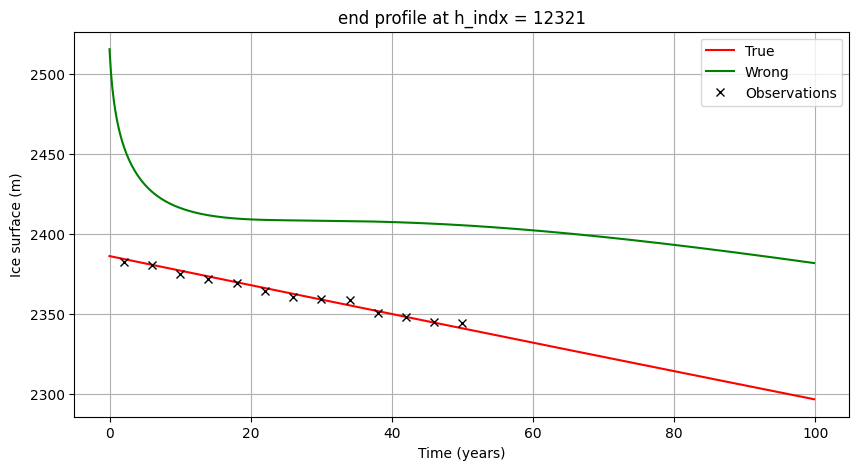

In [9]:
nt = ensemble_true_state.shape[1]; num_steps = nt-1
ndim = ensemble_true_state.shape[0]
hdim = ndim//6 # [h,u,v,bed,f]

Lx, Ly = datasets_tw["Lxy"][0], datasets_tw["Lxy"][1]
nx, ny = datasets_tw["nxy"][0], datasets_tw["nxy"][1]
mx,my = get_grid_dimensions(nx,ny,hdim)
# lets get the middle index
# vert_prof, horiz_prof = midprofiles_coords(mx,my,hdim)
# print(f"Vertical profile at x = {vert_prof}, Horizontal profile at y = {horiz_prof}")
ix,iy= midindices(mx,my)
print(f"Midpoint indices ix = {ix}, iy = {iy}")

# define profile flag
profile_flag = "end" # begining, middle, end, random

if profile_flag == "begining":
    h_indx = 0 # first profile
elif profile_flag == "middle":
    # h_indx = ix*iy # middle profile
    # h_indx = ix*iy + iy//2
    # h_indx = (ix*(my-1)) + (my-1)//2
    # h_indx = ix*(my-1) + 0
    h_indx = ((ix//2)*(my-1)) + (iy)//2 #(ix/2,iy/2) point
elif profile_flag == "end":
    h_indx = (mx-1)*(my-1) + 0
    # h_indx = (mx-1)*(my-1) + (my-1)//2
# elif profile_flag == "random":
#     h_indx = np.random.randint(htrue.shape[0])

print(f"At h_indx = {h_indx} profile ")

# plot the ensemble_true_state and ensemble_nurged_state
htrue = ensemble_true_state[hdim:2*hdim,:]
hnurge = ensemble_nurged_state[hdim:2*hdim,:]

h_indx=hdim-2

h_true = htrue[h_indx,:]
h_nurged = hnurge[h_indx,:]

plt.figure(figsize=(10,5))
plt.plot(t[:-1],h_true[:-1],'r',label='True')
plt.plot(t[:-1],h_nurged[:-1],'g',label='Wrong')
obs = w[hdim+h_indx,:]; print(obs.shape,t[ind_m].shape)
plt.plot(t[ind_m],obs,'kx',label="Observations")
plt.xlabel('Time (years)')
plt.ylabel('Ice surface (m)')
plt.legend()
plt.grid()
plt.title(f"{profile_flag} profile at h_indx = {h_indx}")

In [10]:
print(f"{h_true[:-1].shape} with t: {t[:-1].shape}")
hdim
# 0.25*hdim

(500,) with t: (500,)


12323

In [11]:
Lx, Ly = datasets_tw["Lxy"][0], datasets_tw["Lxy"][1]
nx, ny = datasets_tw["nxy"][0], datasets_tw["nxy"][1]

In [12]:
# h_indx = ix * my + ((my-1) // 2)
# Assuming a nodal grid
row, col = h_indx // (my-1), h_indx % (mx-1)
dx, dy = Lx/(my-1), Ly/(mx-1)
x_h,y_h = col*dx, row*dy

dx,dy = Lx/(mx-1), Ly/(mx-1)
# x_h,y_h = (col+0.5)*dx, (row+0.5)*dy

print(f"At h_indx = {h_indx}, x = {x_h}, y = {y_h}")

At h_indx = 12321, x = 11851.851851851852, y = 82909.09090909091


(12323, 48, 501)
(12323, 48, 501)
(12323, 48, 501)
(12323, 48, 501)


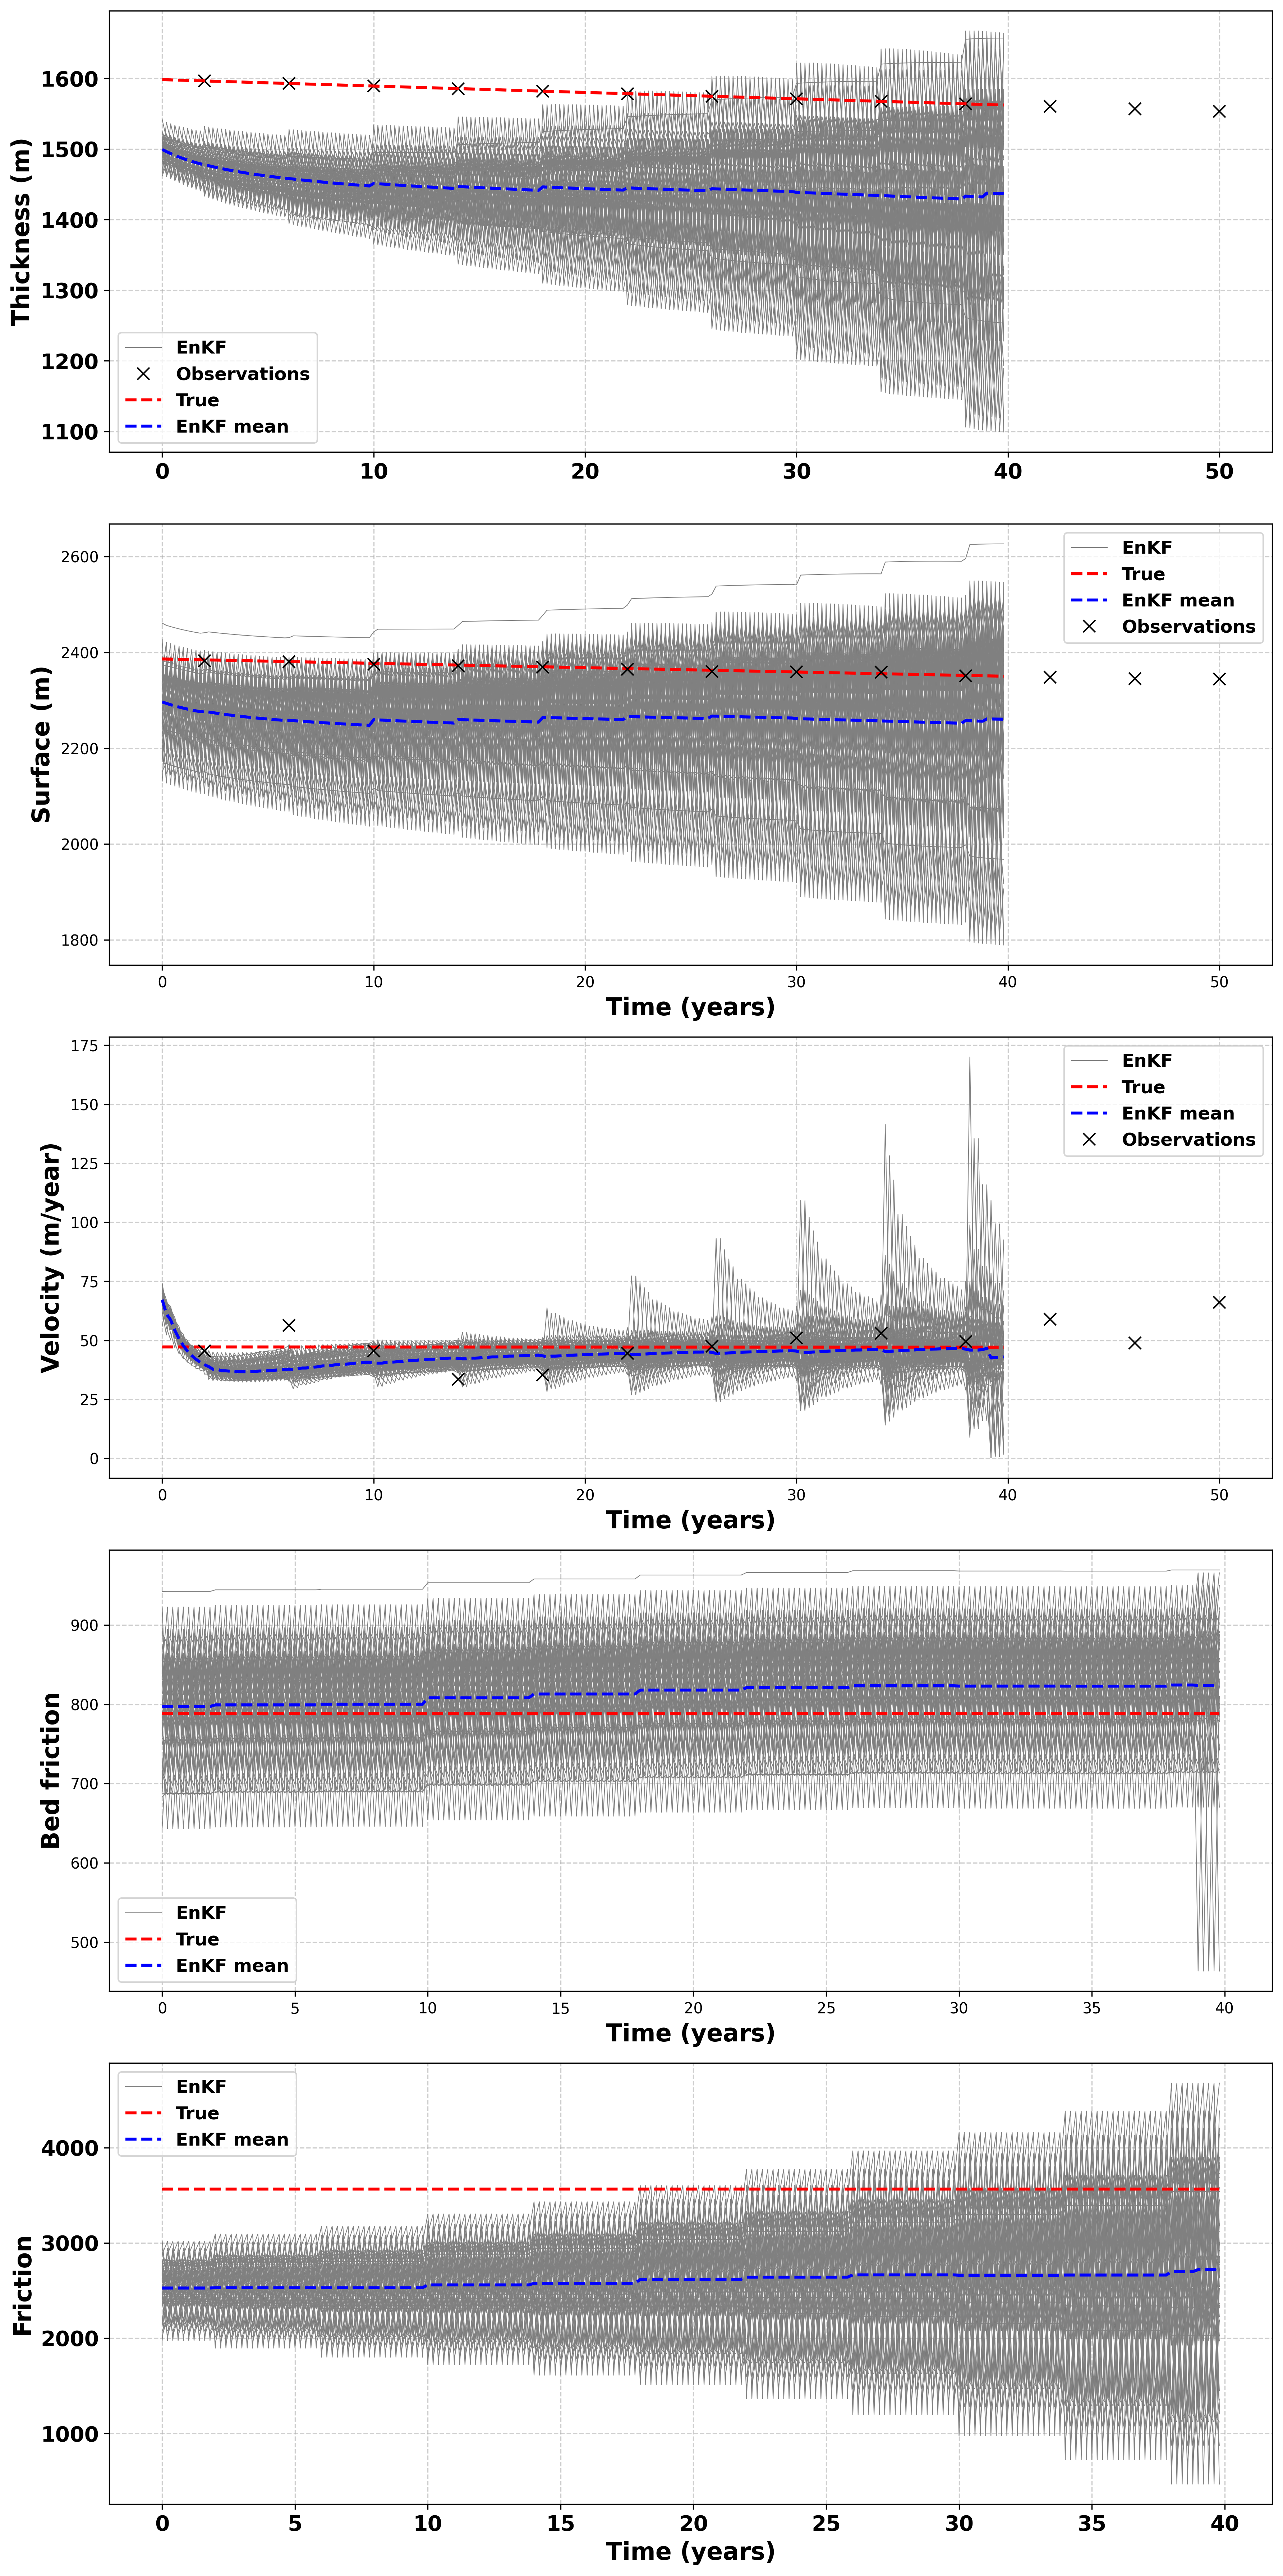

In [ ]:
fig, ax = plt.subplots(5,1, figsize=(12,24), dpi=300)

# h_indx=int(0.2*hdim)
# h_obs = utils_funs.Obs_fun(hu_obs[:hdim,:])
obs_h = w[h_indx,:]
hens = ensemble_vec_mean[:hdim,:]
htrue = ensemble_true_state[:hdim,:]
hnurge = ensemble_nurged_state[:hdim,:]
h_true = htrue[h_indx,:]
h_nurged = hnurge[h_indx,:]
h_ens_mean = hens[h_indx,:]
h_mem  = ensemble_vec_full[:hdim,:,:]; print(h_mem.shape)
h_ens_mem = h_mem[h_indx,:,:].T
# h_ob = h_ob[-1,:]
_nt=200
Nens = ensemble_vec_full.shape[1]
for ens in range(Nens):
    ax[0].plot(t[:_nt],h_ens_mem[:_nt,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")

# # ax[0].plot(ts,h_ens_mem[:,:], lw=0.5, color='k',label="DEnKF ens")
ax[0].plot(t[ind_m],obs_h,'kx',label="Observations", markersize=8)

ax[0].plot(t[:_nt],h_true[:_nt],'--r',label='True',linewidth=2)
# ax[0].plot(t[:_nt],h_nurged[:_nt],'--g',label='Wrong',linewidth=2)
ax[0].plot(t[:_nt],h_ens_mean[:_nt],'--b',label=f"{filter_type} mean",linewidth=2)
# # ax[0].plot(t[ind_m],hu_ob[1,:],'kx',label='Observations')
ax[0].legend(prop={"size": 12, "weight": "bold"})
# ax[0].set_ylim([350, 500])
# ax[0].set_xlim([0, 100])
# ax[0].set_xlabel('Time')
ax[0].grid(True, linestyle="--", alpha=0.6)
ax[0].set_ylabel('Thickness (m)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
# ax[0].set_xticklabels(ax[0].get_xticks(), fontweight='bold',fontsize=14)
# ax[0].set_yticklabels(ax[0].get_yticks(), fontweight='bold',fontsize=14)
# remove decinal points from x and y ticks
ax[0].set_xticklabels([int(tick) for tick in ax[0].get_xticks()], fontweight='bold',fontsize=14)
ax[0].set_yticklabels([int(tick) for tick in ax[0].get_yticks()], fontweight='bold',fontsize=14)
# ax[0].set_title(f"{profile_flag} profile at h_indx = {h_indx}")


# Surface plot
s_indx = hdim + h_indx
obs_s = w[s_indx,:]
Sens = ensemble_vec_mean[hdim:2*hdim,:]
Strue = ensemble_true_state[hdim:2*hdim,:]
Snurge = ensemble_nurged_state[hdim:2*hdim,:]
S_true = Strue[h_indx,:]
S_nurge = Snurge[h_indx,:]
S_ens_mean = Sens[h_indx,:]
S_mem  = ensemble_vec_full[hdim:2*hdim,:,:]; print(S_mem.shape)
S_ens_mem = S_mem[h_indx,:,:].T
# h_ob = h_ob[-1,:]
for ens in range(Nens):
    ax[1].plot(t[:_nt],S_ens_mem[:_nt,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")    

ax[1].plot(t[:_nt],S_true[:_nt],'--r',label='True',linewidth=2)
# ax[1].plot(t[:_nt],S_nurge[:_nt],'--g',label='Wrong',linewidth=2)
ax[1].plot(t[:_nt],S_ens_mean[:_nt],'--b',label=f"{filter_type} mean",linewidth=2)
ax[1].plot(t[ind_m],obs_s,'kx',label='Observations', markersize=8)
ax[1].legend(prop={"size": 12, "weight": "bold"})
ax[1].set_xlabel('Time (years)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[1].set_ylabel('Surface (m)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[1].grid(True, linestyle="--", alpha=0.6)
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
# ax[1].set_xlim([0, 100])
# ax[1].set_title(f"{profile_flag} profile at h_indx = {h_indx}")
# save the figure
plt.savefig(f"s_profile_{profile_flag}_sh.png", bbox_inches='tight', dpi=300)  


# velocity plot
u_indx = 2*hdim + h_indx
v_indx = 3*hdim + h_indx
obs_u = w[u_indx,:]
obs_v = w[v_indx,:]
uobs = np.sqrt(obs_u**2 + obs_v**2)
u_true = ensemble_true_state[u_indx,:]
v_true = ensemble_true_state[v_indx,:]
utrue = np.sqrt(u_true**2 + v_true**2)
u_nurge = ensemble_nurged_state[u_indx,:]
v_nurge = ensemble_nurged_state[v_indx,:]
unurge = np.sqrt(u_nurge**2 + v_nurge**2)
u_ens_mean = ensemble_vec_mean[u_indx,:]
v_ens_mean = ensemble_vec_mean[v_indx,:]
uens_mean = np.sqrt(u_ens_mean**2 + v_ens_mean**2)
u_ens_mem  = ensemble_vec_full[u_indx,:,:].T
v_ens_mem  = ensemble_vec_full[v_indx,:,:].T
uens_mem = np.sqrt(u_ens_mem**2 + v_ens_mem**2)
for ens in range(Nens):
    ax[2].plot(t[:_nt],uens_mem[:_nt,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")


ax[2].plot(t[:_nt],utrue[:_nt],'--r',label='True',linewidth=2)
# ax[1].plot(t[:_nt],unurge[:_nt],'--g',label='Wrong',linewidth=2)
ax[2].plot(t[:_nt],uens_mean[:_nt],'--b',label=f"{filter_type} mean",linewidth=2)
ax[2].plot(t[ind_m],uobs,'kx',label='Observations', markersize=8)
ax[2].legend(prop={"size": 12, "weight": "bold"})
ax[2].set_xlabel('Time (years)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[2].set_ylabel('Velocity (m/year)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[2].grid(True, linestyle="--", alpha=0.6)
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
# ax[1].set_xlim([0, 100])
# ax[1].set_title(f"{profile_flag} profile at u_indx = {u_indx} and v_indx = {v_indx}")
# save the figure
plt.savefig(f"hu_profile_{profile_flag}_s.png", bbox_inches='tight', dpi=300)

# bed friction plot
bed_indx = 4*hdim + h_indx
obs_bed = w[bed_indx,:]
bed_true = ensemble_true_state[4*hdim:5*hdim,:]
bed_nurge = ensemble_nurged_state[4*hdim:5*hdim,:]
bed_ens_mean = ensemble_vec_mean[4*hdim:5*hdim,:]
b_true = bed_true[h_indx,:]
b_nurge = bed_nurge[h_indx,:]
b_ens_mean = bed_ens_mean[h_indx,:]
bed_mem  = ensemble_vec_full[4*hdim:5*hdim,:,:]; print(bed_mem.shape)
bed_ens_mem = bed_mem[h_indx,:,:].T
for ens in range(Nens):
    ax[3].plot(t[:_nt],bed_ens_mem[:_nt,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")  

ax[3].plot(t[:_nt],b_true[:_nt],'--r',label='True',linewidth=2)
# ax[3].plot(t[:_nt],b_nurge[:_nt],'--g',label='Wrong',linewidth=2)
ax[3].plot(t[:_nt],b_ens_mean[:_nt],'--b',label=f"{filter_type} mean",linewidth=2)
# ax[3].plot(t[ind_m],obs_bed,'kx',label='Observations', markersize=8)
ax[3].legend(prop={"size": 12, "weight": "bold"})
ax[3].set_xlabel('Time (years)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[3].set_ylabel('Bed topography', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[3].grid(True, linestyle="--", alpha=0.6)
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
# ax[3].set_xlim([0, 100])
# ax[3].set_title(f"{profile_flag} profile at bed_indx = {bed_indx}")
# save the figure
plt.savefig(f"bed_profile_{profile_flag}_s.png", bbox_inches='tight', dpi=300)

#  friction plot
f_indx = 5*hdim + h_indx
obs_fric = w[f_indx,:]
fric_true = ensemble_true_state[5*hdim:,:]
fric_nurge = ensemble_nurged_state[5*hdim:,:]
fric_ens_mean = ensemble_vec_mean[5*hdim:,:]
f_nurge = fric_nurge[h_indx,:]
# print(fric_nurge.shape,fric_true.shape,fric_ens_mean.shape)
f_true = fric_true[h_indx,:]
f_ens_mean = fric_ens_mean[h_indx,:]
fric_mem  = ensemble_vec_full[5*hdim:6*hdim,:,:]; print(fric_mem.shape)
fric_ens_mem = fric_mem[h_indx,:,:].T
for ens in range(Nens):
    ax[4].plot(t[:_nt],fric_ens_mem[:_nt,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")     

ax[4].plot(t[:_nt],f_true[:_nt],'--r',label='True',linewidth=2)
# ax[4].plot(t[:_nt],fric_nurge[:_nt],'--g',label='Wrong',linewidth=2)
ax[4].plot(t[:_nt],f_ens_mean[:_nt],'--b',label=f"{filter_type} mean",linewidth=2)
# ax[4].plot(t[ind_m],obs_fric,'kx',label='Observations', markersize=8)
ax[4].legend(prop={"size": 12, "weight": "bold"})
ax[4].set_xlabel('Time (years)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[4].set_ylabel('Friction', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[4].grid(True, linestyle="--", alpha=0.6)
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
# ax[4].set_xlim([0, 100])
# ax[4].set_title(f"{profile_flag} profile at f_indx = {f_indx}")
# save the figure
plt.savefig(f"fric_profile_{profile_flag}_s.png", bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()



In [14]:
np.empty(1)

array([5971.5])

In [15]:
nt = 554
nt if nt<100 else nt/10
nt

554

In [16]:
nt//10

55